In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve,accuracy_score
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
claiments_data = pd.read_csv(filepath_or_buffer="claiments.csv")
claiments_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [4]:
claiments_data.shape

(1340, 7)

In [5]:
claiments_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [6]:
claiments_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [7]:
claiments_data.dropna(inplace=True)

In [8]:
claiments_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [11]:
claiments_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1096 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1096 non-null   int64  
 1   ATTORNEY  1096 non-null   int64  
 2   CLMSEX    1096 non-null   float64
 3   CLMINSUR  1096 non-null   float64
 4   SEATBELT  1096 non-null   float64
 5   CLMAGE    1096 non-null   float64
 6   LOSS      1096 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 68.5 KB


In [12]:
claiments_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [14]:
X = claiments_data.drop(labels=['CASENUM',"ATTORNEY"],axis=1)

In [15]:
y = claiments_data['ATTORNEY']

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,shuffle=True,random_state=101)

In [33]:
random_forest_model = RandomForestClassifier(n_estimators=100,max_depth=5)
random_forest_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_pred_train = random_forest_model.predict(X_train)

In [35]:
y_pred_train

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,

In [36]:
y_pred_test = random_forest_model.predict(X_test)
y_pred_test

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

In [37]:
accuracy_score(y_train,y_pred_train)

0.7511415525114156

In [38]:
confusion_matrix(y_train,y_pred_train)

array([[359,  90],
       [128, 299]])

In [39]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       449
           1       0.77      0.70      0.73       427

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



0.7498943788695149


Text(0, 0.5, 'True Positive Rate')

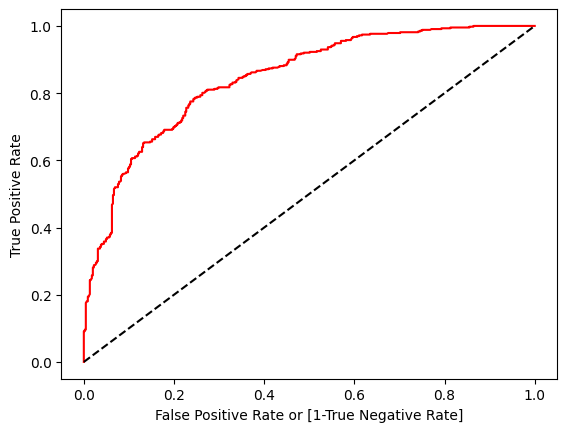

In [40]:
fpr,tpr,thresholds = roc_curve(y_train,random_forest_model.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'Random Forest model (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

In [41]:
accuracy_score(y_test,y_pred_test)

0.7136363636363636

In [42]:
confusion_matrix(y_test,y_pred_test)

array([[95, 34],
       [29, 62]])

In [43]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.74      0.75       129
           1       0.65      0.68      0.66        91

    accuracy                           0.71       220
   macro avg       0.71      0.71      0.71       220
weighted avg       0.72      0.71      0.71       220



0.7088763949229065


Text(0, 0.5, 'True Positive Rate')

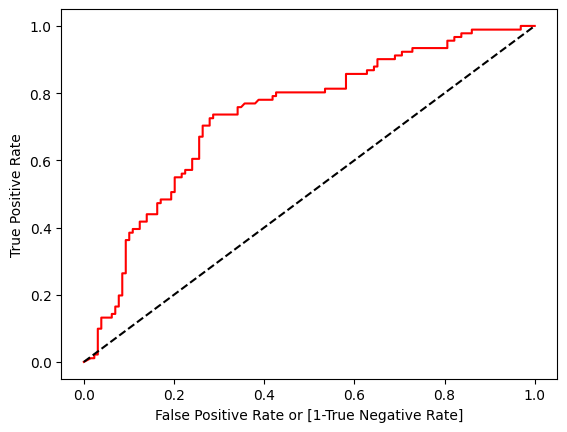

In [44]:
fpr,tpr,thresholds = roc_curve(y_test,random_forest_model.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'Random Forest model (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

In [46]:
grid_search = GridSearchCV(estimator=random_forest_model,param_grid={"max_depth":[5,6,7,8,9],
                                                                     "criterion":['gini','entropy'],
                                                                                  "n_estimators":[50,70,90,110,130,150]})
grid_search.fit(X,y)

,estimator,RandomForestC...r(max_depth=5)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 6, ...], 'n_estimators': [50, 70, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [47]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 50}
0.7344665836446659


In [48]:
adaboost_classifier = AdaBoostClassifier()
adaboost_classifier.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [49]:
y_pred_train = adaboost_classifier.predict(X_train)

In [50]:
y_pred_test  =adaboost_classifier.predict(X_test)

In [51]:
y_pred_train

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,

In [52]:
y_pred_train

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,

In [53]:
accuracy_score(y_train,y_pred_train)

0.726027397260274

In [54]:
confusion_matrix(y_train,y_pred_train)

array([[343, 106],
       [134, 293]])

In [57]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       449
           1       0.73      0.69      0.71       427

    accuracy                           0.73       876
   macro avg       0.73      0.73      0.73       876
weighted avg       0.73      0.73      0.73       876



0.7250512458077539


Text(0, 0.5, 'True Positive Rate')

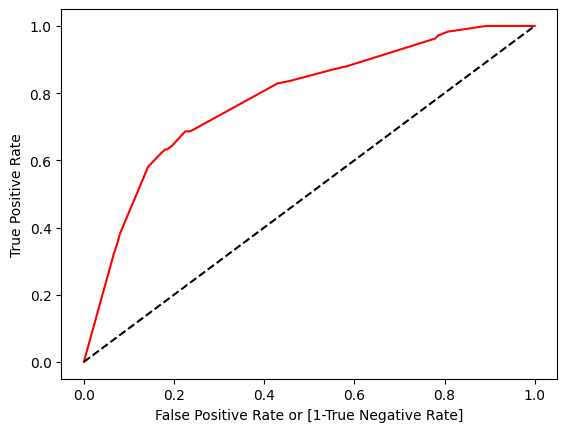

In [61]:
fpr,tpr,thresholds = roc_curve(y_train,adaboost_classifier.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'adaboost_classifier (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

In [58]:
accuracy_score(y_test,y_pred_test)

0.7227272727272728

In [59]:
confusion_matrix(y_test,y_pred_test)

array([[95, 34],
       [27, 64]])

In [60]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       129
           1       0.65      0.70      0.68        91

    accuracy                           0.72       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.73      0.72      0.72       220



0.7198654059119176


Text(0, 0.5, 'True Positive Rate')

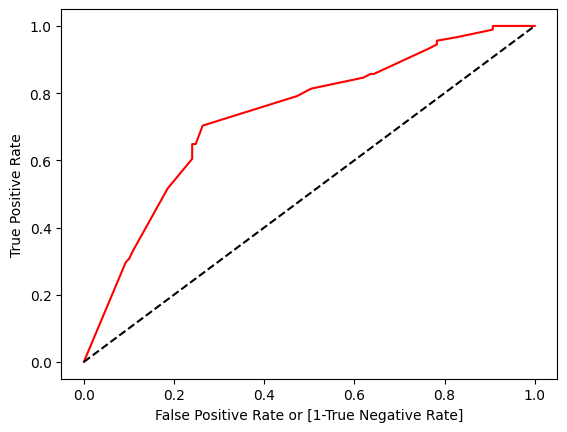

In [62]:
fpr,tpr,thresholds = roc_curve(y_test,adaboost_classifier.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'adaboost_classifier (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

#### STACKING TECHNIQUE

In [69]:
log_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
Kn_model = KNeighborsClassifier()

voting_classifier = VotingClassifier(estimators=[("log",log_model),('dt',dt_model),("KNN",Kn_model)])

voting_classifier.fit(X,y)

y_pred = voting_classifier.predict(X)

accuracy_score(y,y_pred)

0.8394160583941606

In [ ]:
log_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
Kn_model = KNeighborsClassifier()

voting_classifier = VotingClassifier(estimators=[("log",log_model),('dt',dt_model),("KNN",Kn_model)])

voting_classifier.fit(X_train,y_train)

